In [1]:
!pip install polars pandas numpy matplotlib nltk scipy IPython torch transformers xgboost imblearn pystemmer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 824.0/824.0 kB 116.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 158.4 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 165.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 207.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.0/618.0 kB 79.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 201.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 197.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 745.3/745.3 kB 101.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 802.0/802.0 kB 128.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21/21 [transformers] [transformers]ub]]]


In [2]:
# libraries for part 1
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
import re
import sys

pd.set_option('display.max_columns', 200)
plt.style.use("ggplot")

# Libraries for part 2
from sklearn.feature_extraction.text import CountVectorizer
import scipy.sparse
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

# libraries part bert
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModel, AutoConfig, logging

import os
import gc; gc.enable()
from IPython.display import clear_output

In [6]:
df = pd.read_csv('./data/995,000_rows_small.csv', nrows=110_000, usecols=['type','content'])
df['content'] = df['content'].str.replace('\n','').str.replace('\t','').astype('str')
df = df.rename(columns={'content':'title', 'type':'isfake'})

real_labels = ['reliable']
fake_labels = ["fake", "conspiracy", "rumor", "unreliable", "juncsci", "hate", "political", "satire", "bias"]
drop_labels = ['unknown', 'nan', '2018-02-10 13:43:39.521661']

df = df.loc[~df['isfake'].isin(drop_labels)]
df['isfake'] = df['isfake'].map(lambda x : 0 if x in real_labels else 1)

df = df.iloc[:100_000] # limit to 100k samples

x,y = df['title'], df['isfake']
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, stratify=y, random_state=1000)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=1000)

print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

del df
gc.collect();

(80000,)
(10000,)
(10000,)


In [7]:
class TitleDataset(Dataset):
    def __init__(self, x, y, tokenizer, size=128):
        self.encodings = tokenizer(
            list(x),
            add_special_tokens = True,
            padding = 'max_length',
            max_length = size,
            truncation = True,
        )
        self.applies = y
        print('dataset initialized!')

    def __getitem__(self, idx):
        item = {k:torch.tensor(v[idx]) for k,v in self.encodings.items()}
        item['isfake'] = torch.tensor(self.applies.iloc[idx]).float()
        return item

    def __len__(self):
        return len(self.applies)

# roberta encoder/model
class BERTRegressor(nn.Module):
    def __init__(self, _pretrained_model='roberta-base'):
        super().__init__()
        os.environ['TOKENIZERS_PARALLELISM'] = 'true'
        
        # tokenizer-encoder
        self.config = AutoConfig.from_pretrained(_pretrained_model)
        self.encoder = AutoModel.from_pretrained(_pretrained_model, config=self.config)
        self.tokenizer = AutoTokenizer.from_pretrained(_pretrained_model)
        
        clear_output()
        print('model initialized!')

        # model
        self.fc1 = nn.Linear(2*self.config.hidden_size, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 256)
        self.fc4 = nn.Linear(256, 16)
        self.fc5 = nn.Linear(16, 1)
        self.do1 = nn.Dropout(0.5)
        self.do2 = nn.Dropout(0.35)
        self.do3 = nn.Dropout(0.2)
        self.do4 = nn.Dropout(0.2)

    def max_mean_pooling(self, input_ids, attention_mask, token_type_ids=None):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        last_layer = outputs.last_hidden_state
        mask = attention_mask.unsqueeze(-1).expand(last_layer.size()).float()
        
        mean_vectors = (last_layer * mask).sum(1) / mask.sum(1)
        
        last_layer[mask == 0] = -1e9
        max_vectors,_ = torch.max(last_layer, 1)

        vectors = torch.cat((mean_vectors, max_vectors), 1)
        return vectors
        
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        x = self.max_mean_pooling(input_ids, attention_mask)
        x = self.do1(F.relu(self.fc1(x)))
        x = self.do2(F.relu(self.fc2(x)))
        x = self.do3(F.relu(self.fc3(x)))
        x = self.do4(F.relu(self.fc4(x)))
        x = self.fc5(x)
        return x.float()

    def predict(self, outputs):
        return (outputs > 0).float().squeeze(-1)

In [8]:
# initialization
model = BERTRegressor(_pretrained_model='distilbert/distilbert-base-uncased')
losses, avg_losses, val_f1s = [],[],[]
jdx = 1

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device {}'.format(device))

print(f'Training on {x_train.shape[0]} samples, validating on {x_val.shape[0]} samples')
model.to(device)

dataset = TitleDataset(x_train, y_train, model.tokenizer)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

val_dataset = TitleDataset(x_val, y_val, model.tokenizer)
val_loader = DataLoader(val_dataset, batch_size=32)

model initialized!
Using device cuda
Training on 80000 samples, validating on 10000 samples
dataset initialized!
dataset initialized!


Epoch: 2/2, Batch: 1250/1250, Loss: 0.0072, Avg: 0.0959    
Best Validation Score: 0.9782


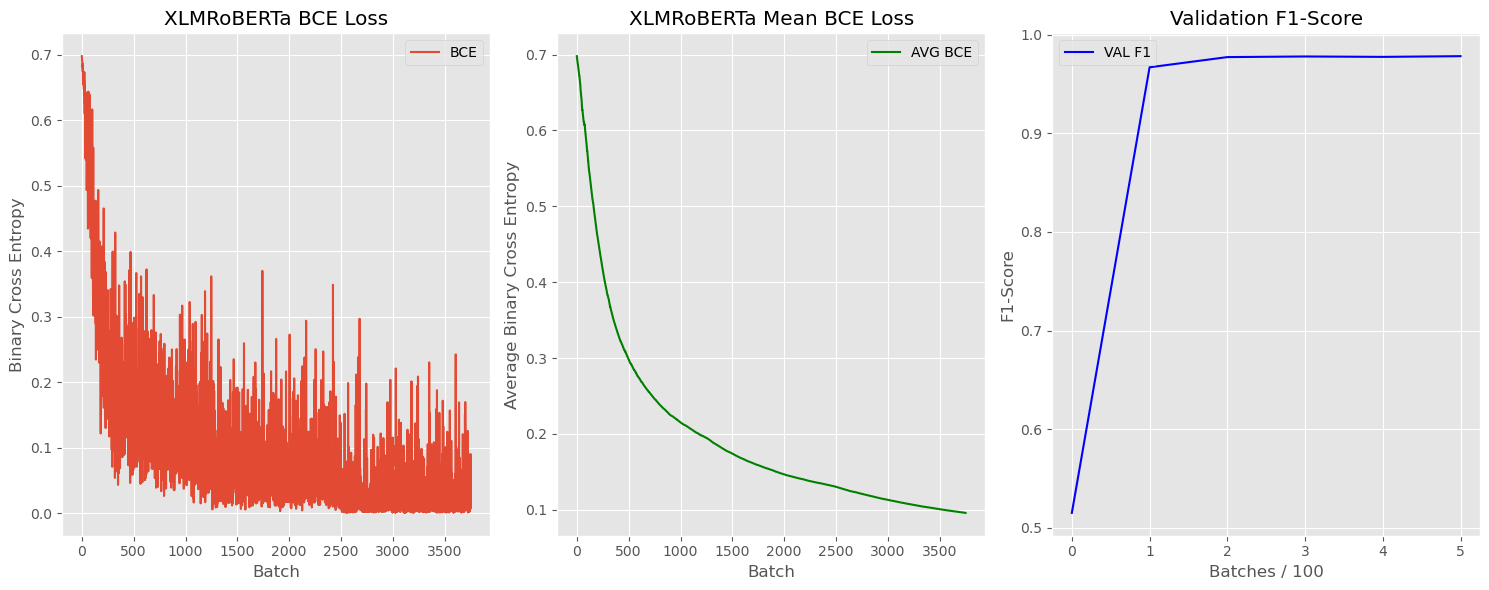

In [15]:
# training loop
lr = 2e-5
epsilon = 1e-6
weight_decay = 0.01

no_decay = ['bias','LayerNorm.weight']
optimizer_grouped_parameters = [
{"params": [p for n, p in model.encoder.named_parameters() if not any(nd in n for nd in no_decay)], "weight_decay": weight_decay, "lr": lr},
{"params": [p for n, p in model.encoder.named_parameters() if any(nd in n for nd in no_decay)], "weight_decay": 0.0, "lr": lr},
{'params': model.fc1.parameters(), 'lr': lr, 'weight_decay': weight_decay},
{'params': model.fc2.parameters(), 'lr': lr, 'weight_decay': weight_decay},
{'params': model.fc3.parameters(), 'lr': lr, 'weight_decay': weight_decay},
{'params': model.fc4.parameters(), 'lr': lr, 'weight_decay': weight_decay},
{'params': model.fc5.parameters(), 'lr': lr, 'weight_decay': weight_decay}
]

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(
    optimizer_grouped_parameters,
    lr=lr,
    eps=epsilon,
)

scaler = torch.amp.GradScaler('cuda')
epochs = 2
for e in range(epochs):
    # batches
    for idx,batch in enumerate(loader):
        # tokenization
        inputs = {k:v.to(device) for k,v in batch.items() if k != 'isfake'}
        labels = batch['isfake'].unsqueeze(-1).to(device)

        # optimization
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            preds = model(**inputs)
            loss = criterion(preds, labels)
        
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
            
        # tracking
        losses.append(loss.item())
        avg_losses.append(np.mean(losses))
        sys.stdout.write(f'\rEpoch: {e+1}/{epochs}, Batch: {idx+1}/{len(loader)}, Loss: {loss.item():.4f}, Avg: {np.mean(losses):.4f}    ')

        if jdx == 1 or jdx % 750 == 0:
            with torch.no_grad():
                    total_val_preds, total_val_labels = [],[]
                    for batch in val_loader:
                        # tokenization
                        inputs = {k:v.to(device) for k,v in batch.items() if k != 'isfake'}
                        labels = batch['isfake'].unsqueeze(-1).to(device)
                    
                        total_val_preds += model.predict(model(**inputs)).squeeze(-1).cpu().numpy().tolist()
                        total_val_labels += labels.squeeze(-1).cpu().numpy().tolist()
        
                    val_f1s.append(f1_score(total_val_preds, total_val_labels))

        jdx += 1

print("\nBest Validation Score: {:.4f}".format(max(val_f1s)))


# plot loss progression
plt.figure(figsize=(15,6))
plt.subplot(1,3,1)
plt.plot(losses, label='BCE')
plt.xlabel('Batch')
plt.ylabel('Binary Cross Entropy')
plt.title('XLMRoBERTa BCE Loss')
plt.legend()
plt.subplot(1,3,2)
plt.plot(avg_losses, label='AVG BCE', color='green')
plt.xlabel('Batch')
plt.ylabel('Average Binary Cross Entropy')
plt.title('XLMRoBERTa Mean BCE Loss')
plt.legend()
plt.tight_layout()
plt.subplot(1,3,3)
plt.plot(val_f1s, label='VAL F1', color='blue')
plt.xlabel('Batches / 100')
plt.ylabel('F1-Score')
plt.title('Validation F1-Score')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# save
torch.save(model.state_dict(), "distilbert_model__1.pth")

# # load
# model = BERTRegressor(_pretrained_model='distilbert-base-cased')
# model.load_state_dict(torch.load("distilbert_model__1.pth"))
# model.eval()

In [17]:
# Uncompiled patterns for polars later
import nltk
import Stemmer
nltk.download('stopwords')
clear_output()

email_str = r'[^ \n,"]+@[^ \n,"]+\.[^ \n,"]+'
date_str = r'[0-9]{2,4}[-/][0-9]{2,4}[-/][0-9]{2,4}'
url_str = r'(?:http)?s?(?://)?[^ \n,"]+\.[a-z]{2,}[^ \n,"]+'
num_str = r'[0-9]+[,.]?[0-9]*'
special_str = r'[^a-zA-Z\-<>\'’‘ʼ′＇]'
apostrephe_str = r'\'’‘ʼ′＇'
ws_str = r'\s+'

# Pattern strings — shared with Task 2 (Polars uses these directly)
email_re = re.compile(email_str)
date_re = re.compile(date_str)
url_re = re.compile(url_str)
num_re = re.compile(num_str)
special_re = re.compile(special_str)
apostrephe_re = re.compile(apostrephe_str)
ws_re = re.compile(ws_str)

# Initialize NLTK Stop words and PyStemmer
stop_words = set(stopwords.words("english"))
stemmer = Stemmer.Stemmer("english")

def preprocess_text(doc: str):
    # Cleaning
    lower_case = doc.lower()
    substituted = email_re.sub(" <EMAIL> ", lower_case)
    substituted = date_re.sub(" <DATE> ", substituted)
    substituted = url_re.sub(" <URL> ", substituted)
    substituted = num_re.sub(" <NUM> ", substituted)
    no_specials = special_re.sub(" ", substituted)
    no_apostrophes = apostrephe_re.sub("", no_specials)
    cleaned = ws_re.sub(' ', no_apostrophes).strip()

    # Stemming and Filtering
    words = [w for w in cleaned.split() if w not in stop_words]
    return " ".join(stemmer.stemWords(words))

In [20]:
# liar dataset
liar_train = pd.read_table('./liar_dataset/train.tsv').iloc[:,[1,2]]
liar_val = pd.read_table('./liar_dataset/valid.tsv').iloc[:,[1,2]]
liar_test = pd.read_table('./liar_dataset/test.tsv').iloc[:,[1,2]]

liar_train.columns = ['isfake','title']
liar_val.columns = ['isfake','title']
liar_test.columns = ['isfake','title']

df = pd.concat([liar_train, liar_val, liar_test], axis=0)

df.columns = ['isfake','title']
df['title'] = df['title'].apply(preprocess_text)

real_labels = ['true']
fake_labels = ['false','pants-fire','half-true','barely-true','mostly-true']

df['isfake'] = df['isfake'].apply(lambda x : 0 if x in real_labels else 1)
X, y = df['title'], df['isfake']

liar_val_dataset = TitleDataset(X, y, model.tokenizer)
liar_val_loader = DataLoader(liar_val_dataset, batch_size=32)

dataset initialized!


F1-Score: 0.9092927912538435
              precision    recall  f1-score   support

         0.0       0.01      0.17      0.02       108
         1.0       0.99      0.84      0.91     12680

    accuracy                           0.83     12788
   macro avg       0.50      0.50      0.46     12788
weighted avg       0.98      0.83      0.90     12788



<Figure size 1600x1400 with 0 Axes>

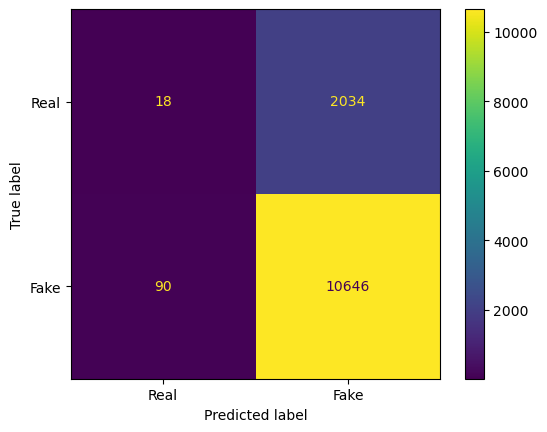

In [21]:
# evaluation
total_val_preds, total_val_labels = [],[]
with torch.no_grad():
    for batch in liar_val_loader:
        # tokenization
        inputs = {k:v.to(device) for k,v in batch.items() if k != 'isfake'}
        labels = batch['isfake'].unsqueeze(-1).to(device)
    
        total_val_preds += model.predict(model(**inputs)).squeeze(-1).cpu().numpy().tolist()
        total_val_labels += labels.squeeze(-1).cpu().numpy().tolist()

print("F1-Score: {}".format(f1_score(total_val_preds, total_val_labels)))
print(classification_report(total_val_preds, total_val_labels))

cmatrix = confusion_matrix(total_val_labels, total_val_preds)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cmatrix, display_labels=['Real','Fake'])
plt.figure(figsize=(16,14))
plt.style.use('default')
cm_display.plot()
plt.show()
plt.style.use('ggplot')

In [ ]:
# read in data
df_test = pd.read_csv('/kaggle/input/datasets/daniellovespancakes/temporaryable-1/temp.csv').iloc[20000:25000,1:]
df_test

In [ ]:
test_example = pd.DataFrame({'isfake':[1], 'title':['isreal declares random goat as the 1234 new prime minister of chicago']})

df_test_with_example = pd.concat([df_test, test_example], axis=0)
df_test_with_example.tail()

In [ ]:
testset = TitleDataset(df_test)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=0)

with torch.no_grad():
    losses = []
    accs = []
    f1s = []
    total_preds = []
    total_labels = []
    for idx,(titles,labels) in enumerate(testloader):
        inputs = model.tokenizer(list(titles), padding=True, truncation=True, max_length=64, return_tensors='pt')
        inputs = {k:v.to(device) for k,v in inputs.items()}

        preds = model.forward(inputs)
        loss = criterion(preds, labels.float().unsqueeze(-1).to(device))

        pred_labels = (preds > 0).float().squeeze(-1)

        total_labels += [int(l) for l in labels]
        total_preds += [int(p) for p in pred_labels]

        acc = float((pred_labels == labels.to(device)).float().mean())
        f1 = f1_score(pred_labels.cpu().numpy(), labels.to(device).cpu().numpy())

        
        losses += [loss.item()]
        accs += [acc]
        f1s += [f1]
        sys.stdout.write(f'\rBatch: {idx+1}/{len(testloader)}, Loss: {loss.item():.4f}, Avg: {running_loss/(idx+1):.4f}, Acc: {acc:.4f}. F1: {f1:.4f}')


print(f'\nMean BCE Loss: {np.mean(losses):.4f}')
print(f'Mean Accuracy: {np.mean(accs):.4f}')
print(f'Mean F1: {np.mean(f1s):.4f}')
print(classification_report(total_preds, total_labels))



plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.hist(losses, label='loss')
plt.xlabel('Binary Cross Entropy Loss')
plt.title('RoBERTa Loss')
plt.legend
plt.subplot(1,3,2)
plt.hist(accs, label='acc', color='blue')
plt.xlabel('Accuracy')
plt.title('RoBERTa Accuracy')
plt.legend()
plt.subplot(1,3,3)
plt.hist(accs, label='f1', color='green')
plt.xlabel('F1 Score')
plt.title('RoBERTa F1')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# get embeddings
embedding_dims, n = 2*768, x_train.shape[0]
memmap = np.memmap(
    'headline_embeddings_train.dat',
    dtype='float32',
    mode='w+',
    shape=(n, embedding_dims)
)

idx = 0
with torch.no_grad():
    for batch in loader:
        sys.stdout.write(f'\rHeadlines: {idx}/{n}')

        inputs = {k:v.to(device) for k,v in batch.items() if k != 'isfake'}
        applies = batch['isfake'].unsqueeze(-1).to(device)

        vectors = model.max_mean_pooling(**inputs)
        vectors = vectors.cpu().numpy()

        memmap[idx:idx+len(vectors)] = vectors
        idx += len(vectors)
        
        
sys.stdout.write(f'\rHeadlines: {idx}/{n}');

Headlines: 80000/80000

In [11]:
# get embeddings
embedding_dims, n_val = 2*768, x_val.shape[0]
memmap = np.memmap(
    'headline_embeddings_val.dat',
    dtype='float32',
    mode='w+',
    shape=(n_val, embedding_dims)
)

idx = 0
with torch.no_grad():
    for batch in val_loader:
        sys.stdout.write(f'\rHeadlines: {idx}/{n_val}')

        inputs = {k:v.to(device) for k,v in batch.items() if k != 'isfake'}
        applies = batch['isfake'].unsqueeze(-1).to(device)

        vectors = model.max_mean_pooling(**inputs)
        vectors = vectors.cpu().numpy()

        memmap[idx:idx+len(vectors)] = vectors
        idx += len(vectors)
        
        
sys.stdout.write(f'\rHeadlines: {idx}/{n_val}');

Headlines: 10000/10000

In [12]:
embeddings = np.memmap(
    "headline_embeddings_train.dat",
    dtype="float32",
    mode="r",
    shape=(n, embedding_dims)
)

val_embeddings = np.memmap(
    "headline_embeddings_val.dat",
    dtype="float32",
    mode="r",
    shape=(n_val, embedding_dims)
)

x_train_embedded = pd.DataFrame(embeddings, columns=[f'hl_{i}' for i in range(embeddings.shape[1])], index=x_train.index)
x_val_embedded = pd.DataFrame(val_embeddings, columns=[f'hl_{i}' for i in range(val_embeddings.shape[1])], index=x_val.index)
x_train_embedded

,hl_0,hl_1,hl_2,hl_3,hl_4,hl_5,hl_6,hl_7,hl_8,hl_9,hl_10,hl_11,hl_12,hl_13,hl_14,hl_15,hl_16,hl_17,hl_18,hl_19,hl_20,hl_21,hl_22,hl_23,hl_24,hl_25,hl_26,hl_27,hl_28,hl_29,hl_30,hl_31,hl_32,hl_33,hl_34,hl_35,hl_36,hl_37,hl_38,hl_39,hl_40,hl_41,hl_42,hl_43,hl_44,hl_45,hl_46,hl_47,hl_48,hl_49,hl_50,hl_51,hl_52,hl_53,hl_54,hl_55,hl_56,hl_57,hl_58,hl_59,hl_60,hl_61,hl_62,hl_63,hl_64,hl_65,hl_66,hl_67,hl_68,hl_69,hl_70,hl_71,hl_72,hl_73,hl_74,hl_75,hl_76,hl_77,hl_78,hl_79,hl_80,hl_81,hl_82,hl_83,hl_84,hl_85,hl_86,hl_87,hl_88,hl_89,hl_90,hl_91,hl_92,hl_93,hl_94,hl_95,hl_96,hl_97,hl_98,hl_99,...,hl_1436,hl_1437,hl_1438,hl_1439,hl_1440,hl_1441,hl_1442,hl_1443,hl_1444,hl_1445,hl_1446,hl_1447,hl_1448,hl_1449,hl_1450,hl_1451,hl_1452,hl_1453,hl_1454,hl_1455,hl_1456,hl_1457,hl_1458,hl_1459,hl_1460,hl_1461,hl_1462,hl_1463,hl_1464,hl_1465,hl_1466,hl_1467,hl_1468,hl_1469,hl_1470,hl_1471,hl_1472,hl_1473,hl_1474,hl_1475,hl_1476,hl_1477,hl_1478,hl_1479,hl_1480,hl_1481,hl_1482,hl_1483,hl_1484,hl_1485,hl_1486,hl_1487,hl_1488,hl_1489,hl_1490,hl_1491,hl_1492,hl_1493,hl_1494,hl_1495,hl_1496,hl_1497,hl_1498,hl_1499,hl_1500,hl_1501,hl_1502,hl_1503,hl_1504,hl_1505,hl_1506,hl_1507,hl_1508,hl_1509,hl_1510,hl_1511,hl_1512,hl_1513,hl_1514,hl_1515,hl_1516,hl_1517,hl_1518,hl_1519,hl_1520,hl_1521,hl_1522,hl_1523,hl_1524,hl_1525,hl_1526,hl_1527,hl_1528,hl_1529,hl_1530,hl_1531,hl_1532,hl_1533,hl_1534,hl_1535
87838,0.094715,-0.149808,0.149115,-0.154833,-0.220964,-0.101991,-0.295370,-0.246096,-0.243381,0.116578,0.290207,0.049035,-0.123752,0.035861,0.202523,0.291706,-0.041386,0.013749,0.201370,0.168996,-0.183351,0.111204,0.001416,-0.130114,-0.045988,-0.195244,0.269546,0.049559,-0.101949,0.804756,0.143550,0.726118,0.176482,-0.094835,-0.632673,-0.072270,0.033514,-0.278877,0.228842,0.157506,-0.310070,0.340694,0.564126,-0.005150,0.720682,0.171332,0.050298,0.122740,0.055365,-0.116498,-0.535527,-0.390341,0.053881,0.038314,0.159430,-0.190783,0.500363,-0.006359,0.010638,-0.004379,-0.272471,0.098400,0.028602,-0.251956,0.104695,0.171603,0.149154,-0.035323,0.470699,-0.365275,-0.353622,-0.018340,0.061124,-0.016862,-0.065785,-0.212270,0.421609,-0.301841,0.302497,-0.348739,-0.345873,-0.610051,-0.305236,0.325076,0.073076,0.255427,-0.550639,-0.260986,-0.052358,0.560544,-0.265305,0.354699,-0.033022,0.418632,-0.093634,0.325907,0.044094,0.071660,0.204540,-0.425046,...,0.451419,0.628104,-0.087338,0.869351,-0.065268,0.768888,0.451233,0.765866,0.231212,0.171991,0.384591,0.624996,0.690277,1.173205,-0.266092,0.385791,0.185042,0.188424,0.157185,-0.241579,-0.227514,0.234967,0.227126,1.160783,0.192336,0.065947,0.634116,0.353484,0.280636,-0.306580,0.302536,0.473364,0.919938,-0.228308,0.173566,0.337933,0.562869,0.254754,0.535291,0.692074,0.829656,-0.151265,0.146025,0.297607,0.751179,0.048061,0.033252,-0.260579,0.322699,0.453999,0.519083,0.968315,0.973620,0.747990,0.389039,-0.007776,0.600193,0.057638,-0.667140,0.241121,0.471729,-0.010483,-0.751761,0.358714,0.729165,0.432243,0.502176,-0.319942,0.254398,0.216734,0.843158,0.248185,0.080410,0.340015,0.473488,0.068548,0.268787,-0.091521,0.051202,-0.111237,0.322493,-0.154157,-0.304676,-0.243674,0.827167,-0.474732,0.465790,-0.172474,0.637665,0.329533,0.447540,0.306401,-0.014234,0.326409,-0.184303,0.311898,0.320631,0.275258,0.516643,0.082385
88362,0.235686,-0.486915,0.187626,-0.041015,-0.129069,0.096064,-0.717096,-0.015605,-0.471220,0.221916,0.140557,-0.200228,-0.113290,-0.369100,0.463027,0.314251,0.347757,-0.077791,0.387854,-0.055992,0.418008,-0.006434,-0.170203,-0.504921,0.325168,0.043401,0.154938,0.249331,-0.518347,0.885694,0.444056,0.950524,-0.291441,0.011555,-0.814755,-0.420872,0.147081,-0.262031,-0.380511,0.531830,-0.346521,0.551723,0.775660,0.534278,0.812112,0.455399,-0.403248,0.349857,0.334558,0.000034,-0.786592,-0.254764,0.269234,-0.167450,0.479912,0.029012,0.048281,-0.399291,-0.302110,-0.011078,-0.118406,0.471926,-0.154873,-0.647301,-0.086728,0.335592,-0.254463,0.028075,0.349379,-1.220710,-0.333507,-0.488055,-0.131617,0.138236,-0.553364,-0.192

In [21]:
# smoter = SMOTE(sampling_strategy='minority', random_state=1000)
# x_train_embedded_sm, y_train_sm = smoter.fit_resample(x_train_embedded, y_train)

clf = XGBClassifier(random_state=1000)
clf.fit(x_train_embedded, y_train)
val_preds = clf.predict(x_val_embedded)
print('f1 score: {}'.format(f1_score(y_val, val_preds)))
print(classification_report(y_val, val_preds))

f1 score: 0.6510286191452213
              precision    recall  f1-score   support

           0       0.45      0.25      0.33      4375
           1       0.57      0.76      0.65      5625

    accuracy                           0.54     10000
   macro avg       0.51      0.51      0.49     10000
weighted avg       0.52      0.54      0.51     10000

